# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
# Importing the basic libraries we will require for the project

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Importing the Machine Learning models we require from Scikit-Learn
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Importing the other functions we may require from Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV

# To get diferent metric scores
from sklearn.metrics import confusion_matrix,classification_report

# Code to ignore warnings from function usage
import warnings;
import numpy as np
warnings.filterwarnings('ignore')

## Importing the Data

In [ ]:
# Mounting Google Drive so we can properly load the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Using Pandas to load the data into a variable called data
data = pd.read_csv('/content/drive/MyDrive/Data Science and Machine Learning MIT/Course 4: Classification and Hypothesis Testing/Project #2/ExtraaLearn.csv')

In [ ]:
# Making a copy of the data to another variable to avoid making any unwanted changes to original data
df = data.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# First let's check the shape of the data set to see how many rows and columns we have
df.shape

(4612, 15)

In [ ]:
# First let's check the first rows of the data to see what we are dealing with
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [ ]:
# Let's also check the last few rows as well
df.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


### Observations:

*   Just from the shape and first few rows of data we can see that we have a data set with 4,612 rows and 15 columns.
*   We have an ID column which is unique to each lead and provides no statistical insights for us.  Therefore, this will be a column to drop during the data cleaning process.
*   Looks like we have 4 variables (current_occupation, first_interaction, profile_completed, and last_activity) that take one of three string options which we will probably need to be One-Hot encoded in the data cleaning process
*   We also have 5 variables (print_media_type1, print_media_type2, digital_media, educational_channels, and referral) which are binary variables represented by a Yes or No answer.  We will have to impute values to these so the computer can understand (Yes=1 and No=0) in the data cleaning process.
*   Lastly, we have the status column which seems to be what we will be trying to predict in this case being that we have a 1 or 0 (Yes or No) to represent whether said lead turned into a paying customer or not.












In [ ]:
# Now let's check the data types of each column using the info() code to also gain some extra insight
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

##### **Observations:**
From the above code we can clearly see the data types of all of the 15 columns in the dataset.  Here we have 4 numeric columns of type int (age, website_visits, time_spent_on_website, and status), one numeric column of type float (page_views_per_visit) and the rest are all categorical variables of type object. Once we gain insights from the categorical columns we can one-hot encode or map values when necessary as stated above to make our model be able to extract insights from these variables.  Lastly, we can see that each column contains 4,612 non-null values meaning we don't have any null values that we will need to treat and can therefore skip that step of data cleaning.

In [ ]:
# Last thing before starting EDA will be to check if we have any duplicated entries
df.duplicated().sum()

np.int64(0)

Being that we have no duplicated entries, we are good to move on to EDA.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

In [ ]:
# We will start EDA by using describe() to get some statistics about the numeric columns in our data set.
# We use the .T which is the transform to make the chart better to read
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


*   Potential leads have an average age of about 46 with values ranging from 18 to 63 with a median of 51 years old and doesn't look like there should be any outliers in this column.
*   Potential leads visit the website an average of about 4 times with a median of 3 visits and values ranging from 0 to 30.  The significant gap between the upper quartile of 5 and the max of 30 could indicate upper outliers that we will be able to check out more when looking at the boxplot.
*   Potential leads spend an average of 724 minutes on the website with a median of 376 minutes and values ranging from 0 to 2537.  Again, the significant gap between the upper quartile of about 1337 and the max of 2537 could indicate upper outliers depending on the distribution that we will be able to check out more when looking at the boxplot.
*   Potential leads visit an average of 3 pages per website visit with a median of also about 3 pages with values ranging from 0 to about 18 pages per visit.  There could also potentially be some outliers located in this column that we will have to check out later.
*   status is a column which takes values of 0 or 1 which indicate whether or not potential leads were turned into paying customers.  This is correct based on the fact that the minimum and maximum values are 0 and 1 respectively.  Also, the mean value of about 0.3 tells us that about 30 peercent of potential leads are turned into paying customers which will be the metric we will be trying to increase with our statistical insights.








In [ ]:
# Time to check value counts of each of the categorical variables
# First we make a list of all catrgorical variables
cat_col = list(df.select_dtypes("object").columns)

# Then print the number count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print('-'*50)

ID
EXT4612    1
EXT001     1
EXT002     1
EXT003     1
EXT4596    1
          ..
EXT009     1
EXT008     1
EXT007     1
EXT006     1
EXT005     1
Name: count, Length: 4612, dtype: int64
--------------------------------------------------
current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name

#### Observations:
*   Looking at ID we see the maximum count is one meaning every ID is unique as stated before.  ID columns don't provide any statistical insight so we will drop it before starting out univariate analysis.
*   current_occupation tells us that dominating percentage of potential leads comes from working professionals and the least amount of potential leads coming from students.  We should check the status with this column later to see which group we might want to target more with ads or incentives.
*   first_interaction tells us that first interaction on website or mobile app is relatively even with website having the slight edge in numbers.  Checking this column against status to see which group gets better conversions and whether we should put more money/resources into the website or mobile app.
*   profile_completed tells us that most leads have a medium or high percentage of their profile completed with only about 100 falling in the low category.  By checking this against status we could see if providing more information in a lead's profile leads to higher conversion rates.
*   last_activity tells us that about half of leads last tried seeking information by email with about a quarter which tried seeking info by phone and another quarter trying to seek info by live chats on the website.  By checking this against status, we could see which group of potential leads has the highest conversion rate and put more resources into that by hiring more people to answer emails, hiring more customer service reps to take phone calls, or develop our chatbots more to be able to answer a wider variety of questions.
*   print_media_type1 tells us that a substantial majority of potential leads have not seen the newspaper ad.
*   print_media_type2 tells us that also a substantial majority of potential leads have not seen the magazine ad with a larger percentage of no's than the newspaper ad.
*   digital_media tells us that that a substantial majority of potential leads have also not seen the ad on social media but with more individuals seeing it on social media rather than in newspapers or magazines.
*   educational_channels tells us that again a substantial majority of potential leads have not seen the ad on online forums but the most people have seen the ad on educational forums than any other marketing location.  By checking each one of these ad types against status we could see which ad is bringing in the highest percentage of converting customers and develop strategies to try and increase the budget and spread of ads in those areas.
*   Lastly we have referral which tells us that basically every one of our potential leads besides 93 did not get a referral from someone.  We should definitely check this column against status to see how high the conversion rate of each group is to see if giving out a referral bonus (if there is none in place) or increasing the bonus is worth it and will give us a substantial increase in customer conversion.











In [ ]:
# Before moving onto Univariate analysis, let us drop the ID column for reasons mentioned previously and check to make sure our column is removed
df.drop('ID', axis=1, inplace=True)
df.head()

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


Now that our ID column has successfully been removed it is time to move on to Univariate analysis.

### Univariate Analysis:

In [ ]:
# This function has been used many times in our course and is used to create a histogram and boxplot for the specified data column
def hist_box(data, col):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 6))
    # Adding a graph in each part
    sns.boxplot(data=data, x=col, ax=ax_box, showmeans=True)
    sns.histplot(data=data, x=col, kde=True, ax=ax_hist)
    plt.show()

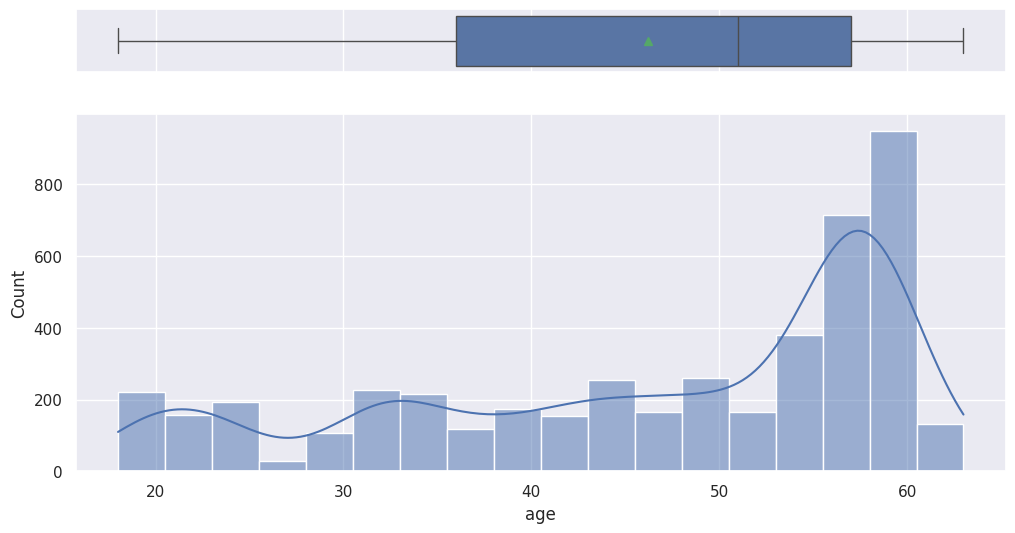

In [ ]:
# This code will create a Histogram and boxplot for the 'age' column
hist_box(df, 'age')

**age-**
age is discrete variable that is left skewed with a majority of values between 55 and 60 years old. This variable has no outliers.

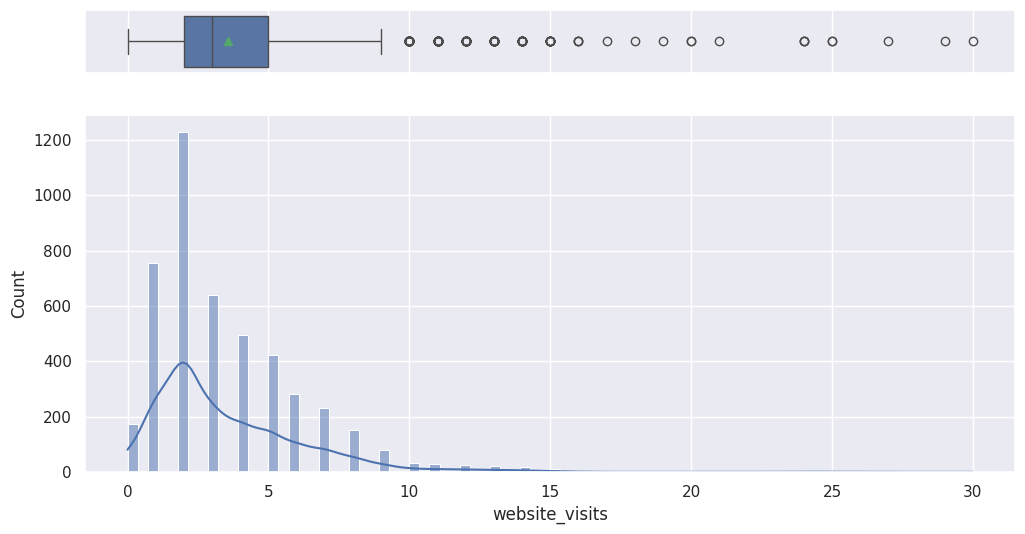

In [ ]:
# This code will create a Histogram and boxplot for the 'website_visits' column
hist_box(df, 'website_visits')

**website_visits-**  website_visits is a discrete variable that is right skewed with a majority of values at 2 website visits. This variable has quite a number of outliers.  These outliers do not look like impossible values as someone could have visited the website 30 times.  Therefore, there will be no need to treat these outliers as we want to keep as much of our original data as possible.

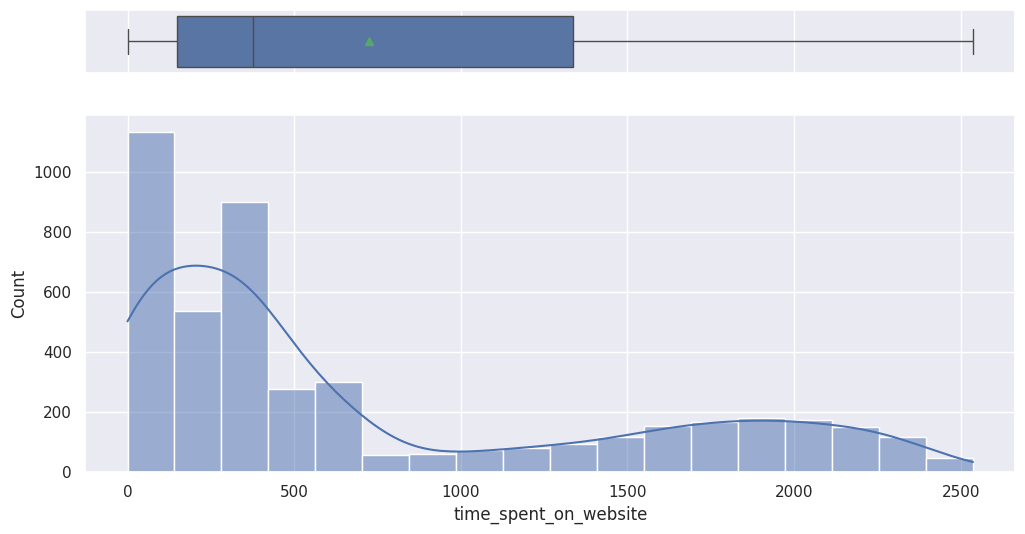

In [ ]:
# This code will create a Histogram and boxplot for the 'time_spent_on_website' column
hist_box(df, 'time_spent_on_website')

**time_spent_on_website-** time_spent_on_website is a discrete variable that is right skewed with a majority of values between about 0 and 400 minutes on the website. It looks like even though we thought earlier that this variable could have some outliers, as shown by the boxplot, it actually does not have any.

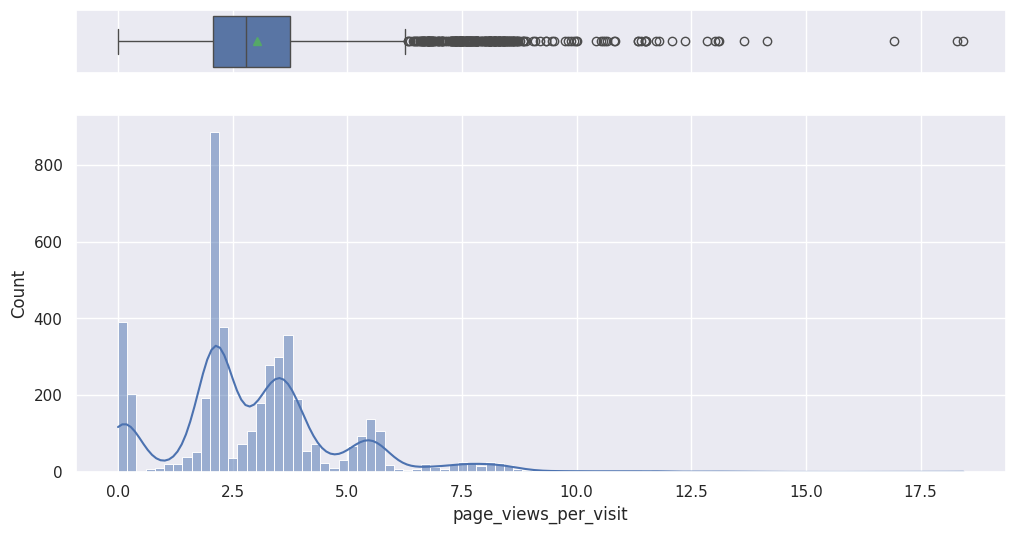

In [ ]:
# This code will create a Histogram and boxplot for the 'page_views_per_visit' column
hist_box(df, 'page_views_per_visit')

**page_views_per_visit-** page_views_per_visit is a continuous variable that is a slightly right skewed multimodal distribution, with peaks at 0, about 2.2, about 3.5, and about 5.5. This variable has quite a number of outliers. These outliers do not look like impossible values as someone could have visited an average of 17 pages per visit if they are taking a class or trying to learn so new information. Therefore, there will be no need to treat these outliers as we want to keep as much of our original data in tact as possible.

In [ ]:
# function to create labeled barplots used many times so far throughout the course


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

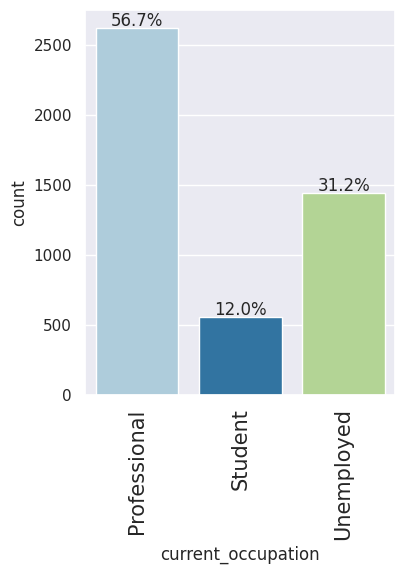

In [ ]:
# This code creates a labeled barplot for current_occupation from our created function with percent values instead of number of samples
labeled_barplot(df,'current_occupation',perc=True)

current_occupation shows 56.7 percent of potential leads in the professional category as the highest and 12 percent of potential leads in the student category.  Being that this service is targeted towards proffesionals and students, the former makes perfect sense whereas the latter seems on the low end.  We might want to try and target students even more if possible.

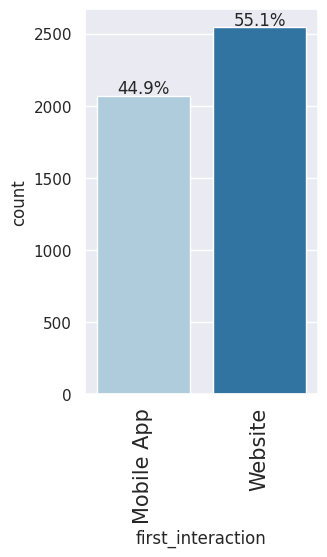

In [ ]:
# This code creates a labeled barplot of first_interaction from our created function with percent values instead of number of samples
labeled_barplot(df,'first_interaction',perc=True)

first_interaction shows 55.1 percent of potential leads having their first interaction with the company by website while 44.9 percent by mobile app.  This is almost a fairly even split implying that both the website and mobile app have adequate resources to attract potential leads.

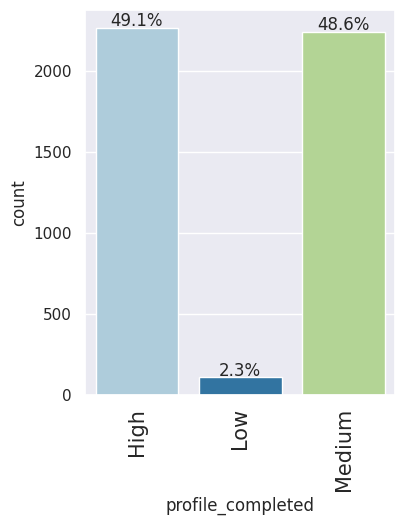

In [ ]:
# This code creates a labeled barplot of profile_completed from our created function with percent values instead of number of samples
labeled_barplot(df,'profile_completed',perc=True)

profile_completed shows 49.1 percent of potential leads having a high percentage of their profile completed followed by 48.6 percent for a medium amount of their profile completed and 2.3 percent for a low amount of their profile completed. This tells us that 97.7 peercent of potential leads have at least 50 percent of their profile completed which is good for us because we can use that information to target courses or ads to users who we think might be interested in them.  We could also try and send extra reminders to users in the low category to get them to update their profile.

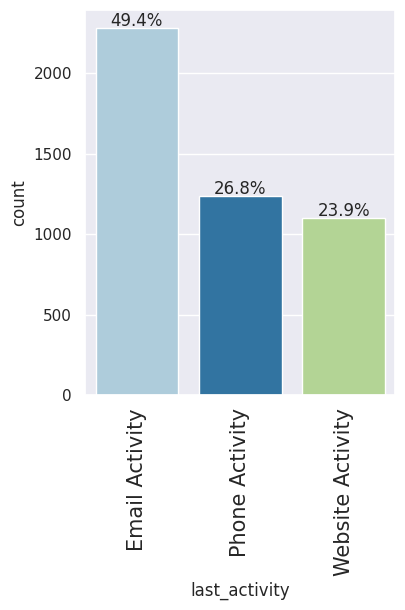

In [ ]:
# This code creates a labeled barplot of last_activity from our created function with percent values instead of number of samples
labeled_barplot(df,'last_activity',perc=True)

last_activity shows 49.4 percent of potential leads having their last interaction with ExtraaLearn via email, 26.8 percent having their last interaction with ExtraaLearn via phone (call or text), and 23.9 percent having their last interaction with ExtraaLearn via the website.  From this we can see that most people interact with the company via email, so, sending out more important messages via email, rather than by phone or website, could be more beneficial to the company.

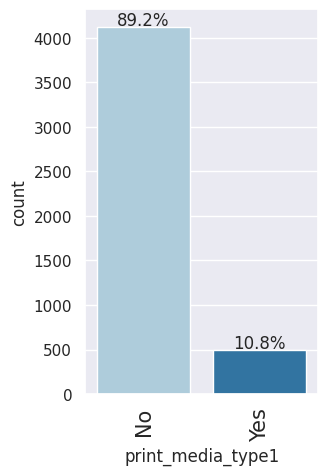

In [ ]:
# This code creates a labeled barplot of print_media_type1 from our created function with percent values instead of number of samples
labeled_barplot(df,'print_media_type1',perc=True)

print_media_type1 shows 89.2 percent of potential leads have not seen ExtraaLearn's ad in the newspaper with the remaining 10.8 percent who have seen the ad.  Obviously we want more people to see our ads, so, we can check these different media types against status during bivariate analysis to see if the different ads in different forms of media lead to higher conversion rates of customers.

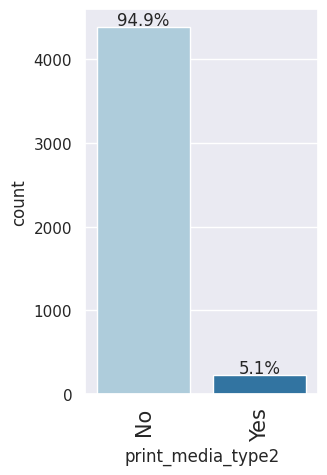

In [ ]:
# This code creates a labeled barplot of print_media_type2 from our created function with percent values instead of number of samples
labeled_barplot(df,'print_media_type2',perc=True)

print_media_type2 shows 94.9 percent of potential leads have not seen ExtraaLearn's ad in the magazine with the remaining 5.1 percent who have seen the ad.  We will check this feature against status for the same reason as stated above.

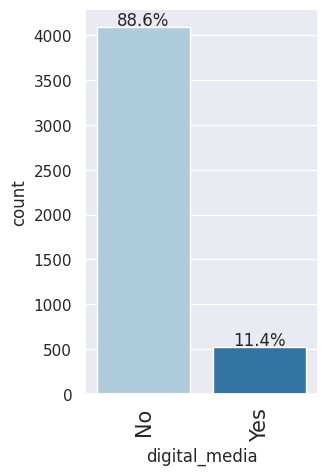

In [ ]:
# This code creates a labeled barplot of digital_media from our created function with percent values instead of number of samples
labeled_barplot(df,'digital_media',perc=True)

digital_media shows 88.6 percent of potential leads have not seen ExtraaLearn's ad on digital platforms with the remaining 11.4 percent who have seen the ad. This has been the ad that the highest percentage of leads have seen so far which we should keep in mind when checking this feature against status.

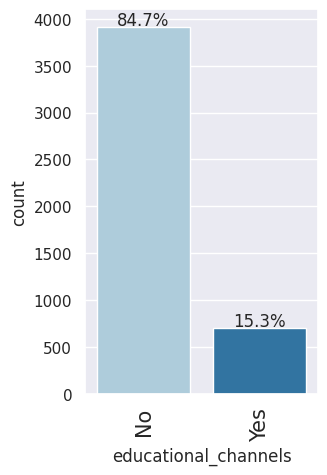

In [ ]:
# This code creates a labeled barplot of educational_channels from our created function with percent values instead of number of samples
labeled_barplot(df,'educational_channels',perc=True)

educational_channels shows 84.7 percent of potential leads have not seen ExtraaLearn's ad on educational channels with the remaining 15.3 percent who have seen the ad. This now is the ad that the highest percentage of leads have seen so far which makes sense being that this is an educational platform so people looking for opportunities after seeing the ad could have a higher conversion rate which we will take a look at during bivariate analysis.

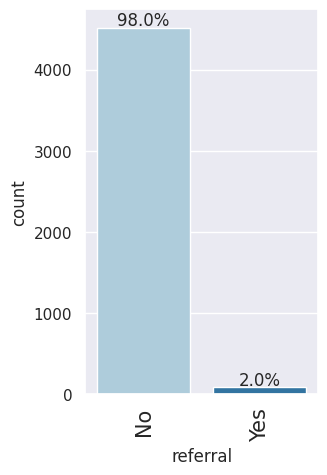

In [ ]:
# This code creates a labeled barplot of referral from our created function with percent values instead of number of samples
labeled_barplot(df,'referral',perc=True)

referral shows that a whopping 98 percent of potential leads did not hear about the company through a reference.  If when checking against status we see that a large percentage of the yesses convert it might be worth it to give a referral bonus to get customers who had a good experience to refer a friend through incentives.

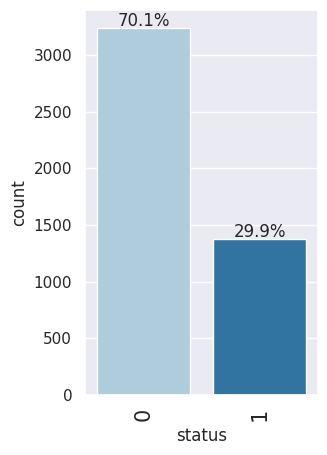

In [ ]:
# This code creates a labeled barplot of status from our created function with percent values instead of number of samples
labeled_barplot(df,'status',perc=True)

status shows that only 29.9 percent of potential leads ended up converting to a paying customer . This is the number we are looking to increase with our business insights gained from EDA and model training.  We will continue to look for ways to do this through bivariate analysis.

### Bivariate Analysis:

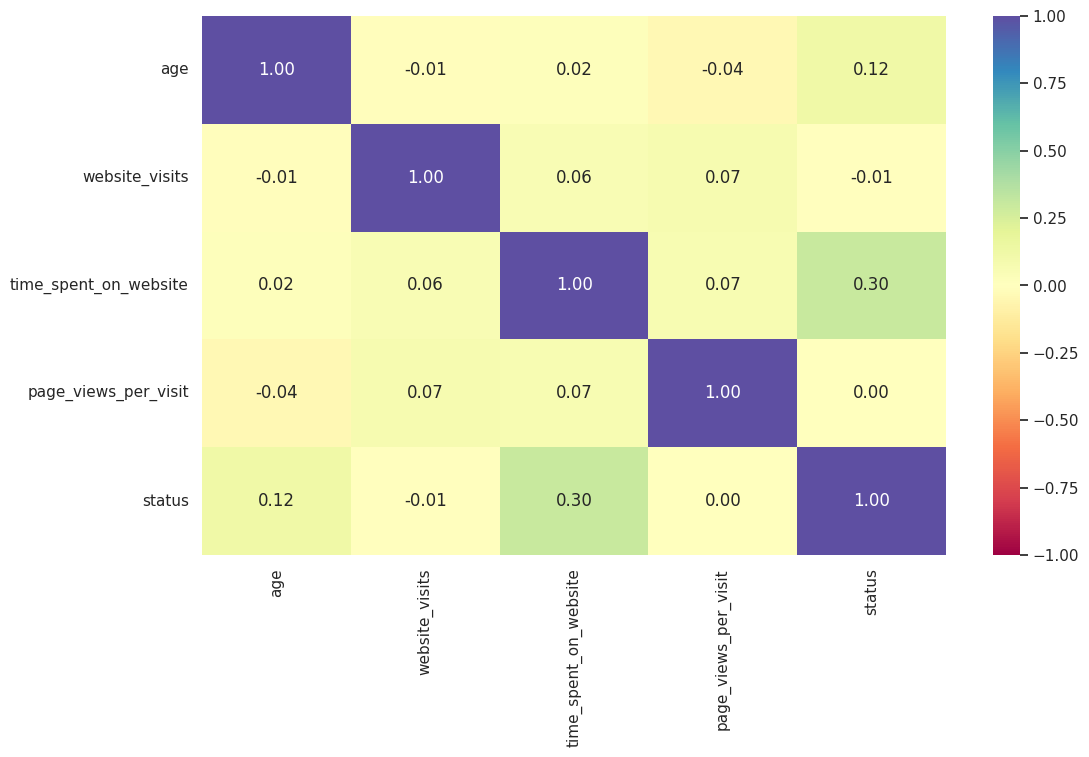

In [ ]:
# This code gets our list of numeric variables and plots a correlation heatmap for us.
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

From the heatmap we can see that most of the correlations are very small numbers in the positive or negative direction, which indicate that they are not correlated with eachother.  There is one slight positive correlation between status and time_spent_on_website which is fine in this case because, status is the variable we are trying to predict, so in the data preparation phase it will be dropped from our X and become our y.

In [ ]:
# We will need to use stacked barplots when comparing the rest of our variables so we will use a code we have seen in other case studies.
# Function to plot stacked bar plots

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins = True).sort_values(
        by = sorter, ascending = False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize = "index").sort_values(
        by = sorter, ascending = False
    )
    tab.plot(kind = "bar", stacked = True, figsize = (count + 1, 5))
    plt.legend(
        loc = "lower left",
        frameon = False,
    )
    plt.legend(loc = "upper left", bbox_to_anchor = (1, 1))
    plt.show()

First, let's answer the given questions before completing our analysis.

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


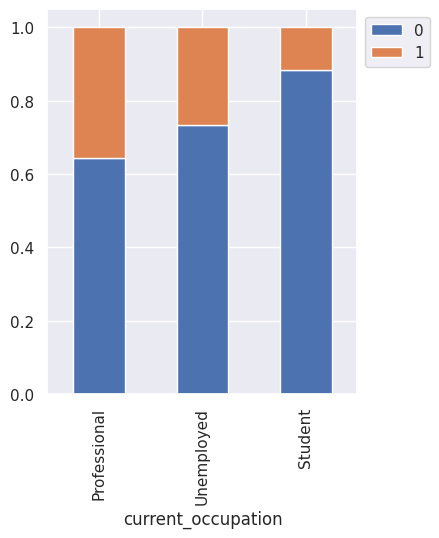

In [ ]:
# We will first use a stacked barplot to find out how current_occupation affects status
stacked_barplot(df, 'current_occupation', 'status')

From this barplot we can see that professionals have the best rate of conversion with about 36 percent becoming paying customers.  Students on the other hand have the lowest with about 12 percent becoming paying customers.  Based on tbis information targeting professionals seems to be working as they have the highest conversion rate but students do not seem to be working.  Therefore, since unemployed boasts more than double the conversion rate of students, it might be best to swap the student targeted marketing to unemployed.  By doing this, we can try to maximize the potential leads in the categories that give you the highest chance at converting any given lead to a paying customer.

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


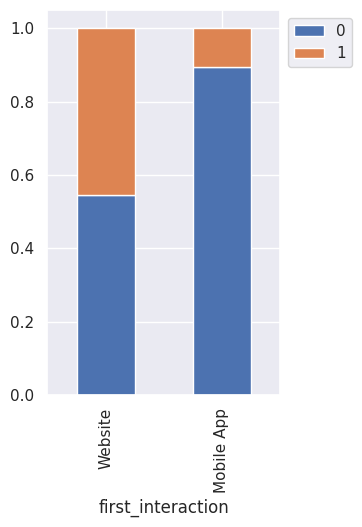

In [ ]:
# We will now use a stacked barplot to find out how first_interaction affects status
stacked_barplot(df, 'first_interaction', 'status')

This barplot shows us that first channel of interaction absolutely has an impact on lead status.  We can see that 46 percent of potential leads that have their first interaction on the website convert to paying customers while only about 11 percent of potential leads that have their first interaction on the app convert to paying customers.  From these numbers it might be best to add more features to the website to attract customers to try and maximize those website numbers.  On the other hand, one could also try adding more features to the app to try and raise that percentage somewhere close to the website numbers but being as the mobile app numbers are starting rather low, this approach would probably be more on the riskier side.

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


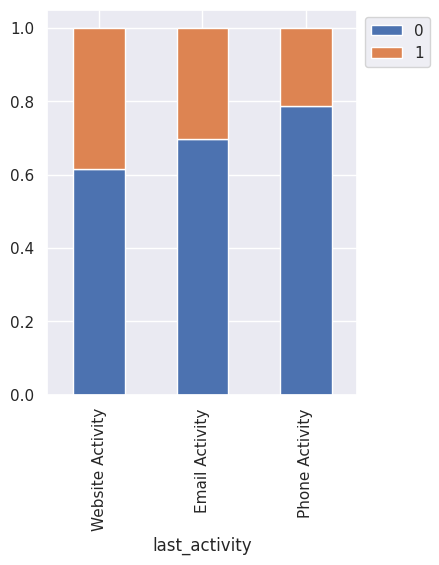

In [ ]:
# We will now use a stacked barplot to find out how last_interaction affects status
stacked_barplot(df, 'last_activity', 'status')

This barplot shows us that last interaction has an impact on lead status. We can see that almost 40 percent of potential leads that have their last interaction via the website convert to paying customers while about 30 percent of potential leads that have their last interaction via email convert to paying customers, and about 21 percent of potential leads that have their last interaction via the phone convert to paying customers. From these numbers it might be best to try and keep on top of those who use the website in order to maximize conversion.  In the future we could also do some deeper research and segment these leads into age brackets and see if it is better to contact certain age groups in different ways.  For example, maybe people ages 50-60 could have a higher converison rate if contacted by phone instead of email or vice versa for the age group of 20-30.

status                0     1   All
print_media_type1                  
All                3235  1377  4612
No                 2897  1218  4115
Yes                 338   159   497
------------------------------------------------------------------------------------------------------------------------


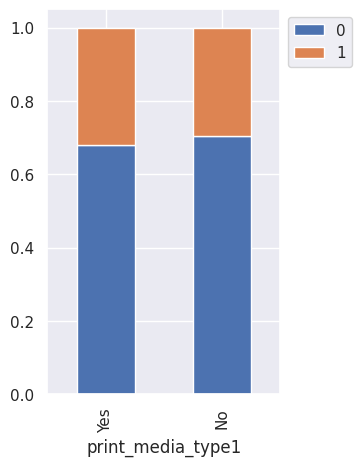

In [ ]:
# We will now use a stacked barplot to find out how print_media_type1 affects status
stacked_barplot(df, 'print_media_type1', 'status')

status                0     1   All
print_media_type2                  
All                3235  1377  4612
No                 3077  1302  4379
Yes                 158    75   233
------------------------------------------------------------------------------------------------------------------------


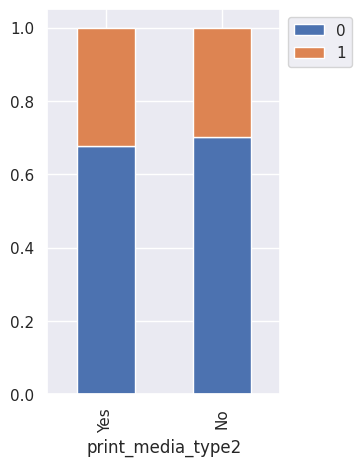

In [ ]:
# We will now use a stacked barplot to find out how print_media_type2 affects status
stacked_barplot(df, 'print_media_type2', 'status')

status            0     1   All
digital_media                  
All            3235  1377  4612
No             2876  1209  4085
Yes             359   168   527
------------------------------------------------------------------------------------------------------------------------


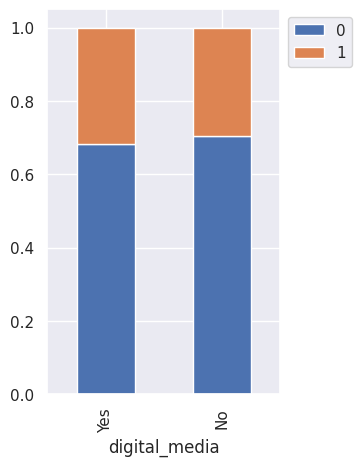

In [ ]:
# We will now use a stacked barplot to find out how digital_media affects status
stacked_barplot(df, 'digital_media', 'status')

status                   0     1   All
educational_channels                  
All                   3235  1377  4612
No                    2727  1180  3907
Yes                    508   197   705
------------------------------------------------------------------------------------------------------------------------


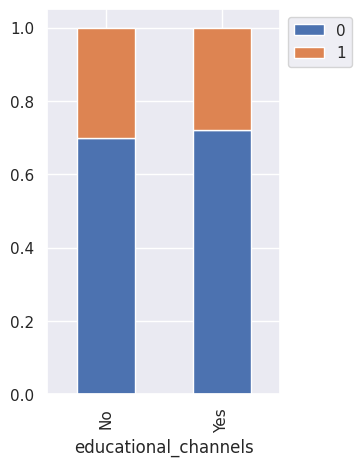

In [ ]:
# We will now use a stacked barplot to find out how educational_channels affects status
stacked_barplot(df, 'educational_channels', 'status')

status       0     1   All
referral                  
All       3235  1377  4612
No        3205  1314  4519
Yes         30    63    93
------------------------------------------------------------------------------------------------------------------------


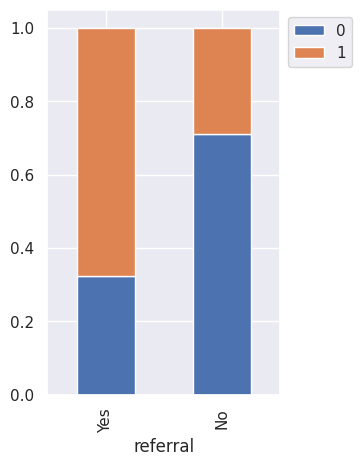

In [ ]:
# We will now use a stacked barplot to find out how referrals affects status
stacked_barplot(df, 'referral', 'status')

From these barplots of each type of recruiting techniques we can see most don't show much of a difference in conversion rate whether the person had seen the ad or not except one.  Referral has a large difference in conversion rate for people who had been referred and had not.  The conversion rate jumps from about 30 percent to about 68 percent if the person is referred.  This means that more referrals gives us a higher chance that these potential leads turn into paying customers and make the company more money.  Therefore, giving already paying customers referral codes where they can get gift cards or some other perks if a person joins with their code would give these customers a greater incentive to tell some friends if they were enjoying our services.

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


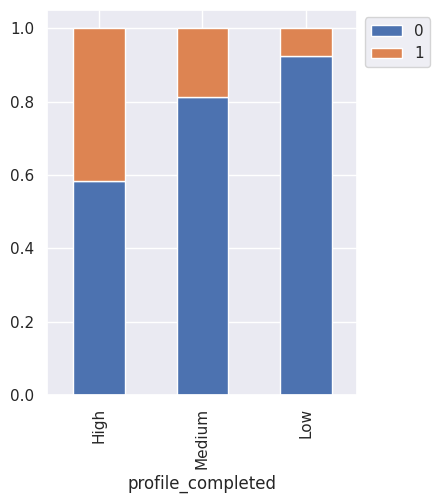

In [ ]:
# We will now use a stacked barplot to find out how profile_completed affects status
stacked_barplot(df, 'profile_completed', 'status')

From the above barplot we can see that having more information about a potential lead does increase the chance of conversion.  The chance of conversion increeases from about 7 percent to about 19 percent to about 42 percent when going from low to medium to high profile completion.  In order to try and maximize our chances at more paying customers we can incentivize potential leads by giving them a reward (something like 5 percent off their first course enrollment) when they hit over the 75 percent profile completion that puts them into the high category.  Now time to move on to data preprocessing.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

We already mentioned earlier about outliers and how they make sense in this dataset so there will be no need to treat them.  There were also no missing values for us to impute into our dataset.  We will however be mapping and One-hot encoding our categorical features to make them understandable to the computer.

In [ ]:
# First let's map the values of 1 and 0 to yes and no respectively for print_media_type1, print_media_type2, digital_media, education_channels, and referral
dict_features = {'Yes': 1, 'No':0}
df['print_media_type1'] = df.print_media_type1.map(dict_features)
df['print_media_type2'] = df.print_media_type2.map(dict_features)
df['digital_media'] = df.digital_media.map(dict_features)
df['educational_channels'] = df.educational_channels.map(dict_features)
df['referral'] = df.referral.map(dict_features)

In [ ]:
# Checking our data to make sure that what we wanted was achieved and that the columns are of type int
df.head()

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,1,0,1,0,0,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,0,0,0,1,0,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,0,0,1,0,0,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,0,0,0,0,0,1
4,23,Student,Website,High,4,600,16.914,Email Activity,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    4612 non-null   int64  
 1   current_occupation     4612 non-null   object 
 2   first_interaction      4612 non-null   object 
 3   profile_completed      4612 non-null   object 
 4   website_visits         4612 non-null   int64  
 5   time_spent_on_website  4612 non-null   int64  
 6   page_views_per_visit   4612 non-null   float64
 7   last_activity          4612 non-null   object 
 8   print_media_type1      4612 non-null   int64  
 9   print_media_type2      4612 non-null   int64  
 10  digital_media          4612 non-null   int64  
 11  educational_channels   4612 non-null   int64  
 12  referral               4612 non-null   int64  
 13  status                 4612 non-null   int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 504.6+ 

In [ ]:
# Now we can one-hot encode the rest of the object columns
#List of columns to create a dummy variables
col_dummy=['current_occupation','first_interaction','profile_completed','last_activity']
df = pd.get_dummies(df,columns=col_dummy,drop_first=True)

In [ ]:
# Let's check the data again
df.head()

,age,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity
0,57,7,1639,1.861,1,0,1,0,0,1,False,True,True,False,False,False,True
1,56,2,83,0.320,0,0,0,1,0,0,False,False,False,False,True,False,True
2,52,3,330,0.074,0,0,1,0,0,0,False,False,True,False,True,False,True
3,53,4,464,2.057,0,0,0,0,0,1,False,True,True,False,False,False,True
4,23,4,600,16.914,0,0,0,0,0,0,True,False,True,False,False,False,False


In [ ]:
# Changing the type from true and false to integer values of 1 and 0 respectively
col_dummy2 = ['current_occupation_Student','current_occupation_Unemployed','first_interaction_Website','profile_completed_Low','profile_completed_Medium','last_activity_Phone Activity','last_activity_Website Activity']
df[col_dummy2] = df[col_dummy2].astype(int)

In [ ]:
# Let's check the data one last time to make sure everything we wanted has been done
df.head()

,age,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity
0,57,7,1639,1.861,1,0,1,0,0,1,0,1,1,0,0,0,1
1,56,2,83,0.320,0,0,0,1,0,0,0,0,0,0,1,0,1
2,52,3,330,0.074,0,0,1,0,0,0,0,0,1,0,1,0,1
3,53,4,464,2.057,0,0,0,0,0,1,0,1,1,0,0,0,1
4,23,4,600,16.914,0,0,0,0,0,0,1,0,1,0,0,0,0


In [ ]:
# Now let's separate our independent and dependent variables
X = df.drop(["status"], axis=1)
y = df["status"]

In [ ]:
# Now we will split the data in for train to test data.  Let's try and use a 30 percent test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

Now that we are done with our data cleaning and have split our data into training and testing sets, we can move on to building our models.  We will start with a single decision tree.

## **Model evaluation criterion:**

#### **The model can make wrong predictions as:**
1. Predicting a lead will convert to a paying customer and the lead doesn't convert - Loss of resources
2. Predicting a lead will not convert to a paying customer and the customer would have converted - Loss of opportunity

#### **Which case is more important?**
* Predicting a lead will not convert to a paying customer and the customer would have converted.  Losing on a potential source of income for the company because that customer will not be targeted by the team when he should be targeted is what we should be looking to reduce. (Type 2 errors)

#### **How to reduce this loss i.e need to reduce False Negatives?**
* The company wants Recall to be maximized, the greater the Recall lesser the chances of false negatives.

## Building a Decision Tree model

In [ ]:
# First we will set up a function we used when training previous models
# This function will print out the classification report and a heatmap of the confusion matrix of our model's performance so we can compare the different models we will be training
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True,  fmt = '.2f', xticklabels = ['Not Converted', 'Converted'], yticklabels = ['Not Converted', 'Converted'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

In [ ]:
# Let's instantiate our decision tree and then fit the model to our data
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



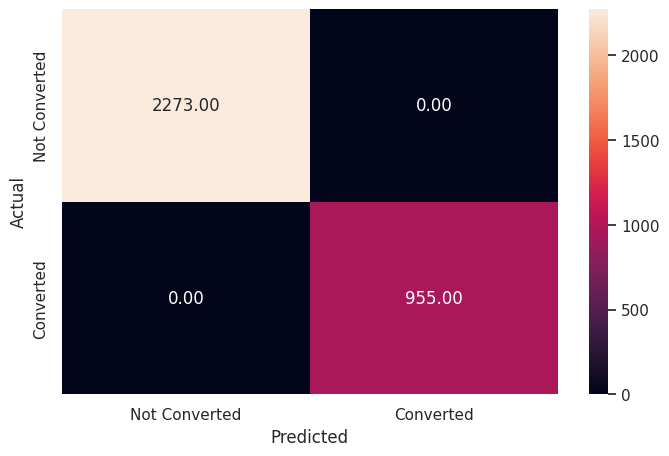

In [ ]:
# Now let's check our model's performance on the training data.
# Being that our model was fit using this data we should expect to see pretty good scores
y_pred_train_dt = d_tree.predict(X_train)
metrics_score(y_train, y_pred_train_dt)

* Looks like our model has performed very well and each sample has been classified correctly.
* Decision trees continue to grow and classify each data point correctly as long as no restrictions are applied, learning all patterns in the training data set.  So now, let's check the performance on test data to see if our model is overfitting.

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       962
           1       0.71      0.70      0.70       422

    accuracy                           0.82      1384
   macro avg       0.79      0.79      0.79      1384
weighted avg       0.82      0.82      0.82      1384



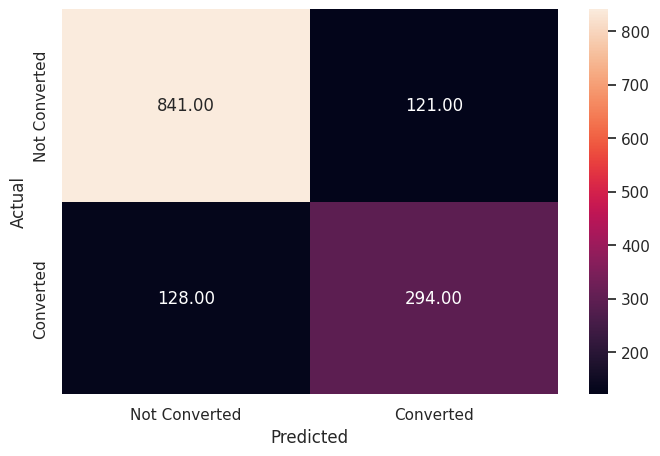

In [ ]:
# This code checks how well our model performs on the test data
y_pred_test_dt = d_tree.predict(X_test)
metrics_score(y_test, y_pred_test_dt)

* Looks like our model was overfitting our training data due to the substantial amount of incorrect predictions on the test data.
* We should try and tune the decision tree to reduce overfitting and make our model more accurate.

## Do we need to prune the tree?

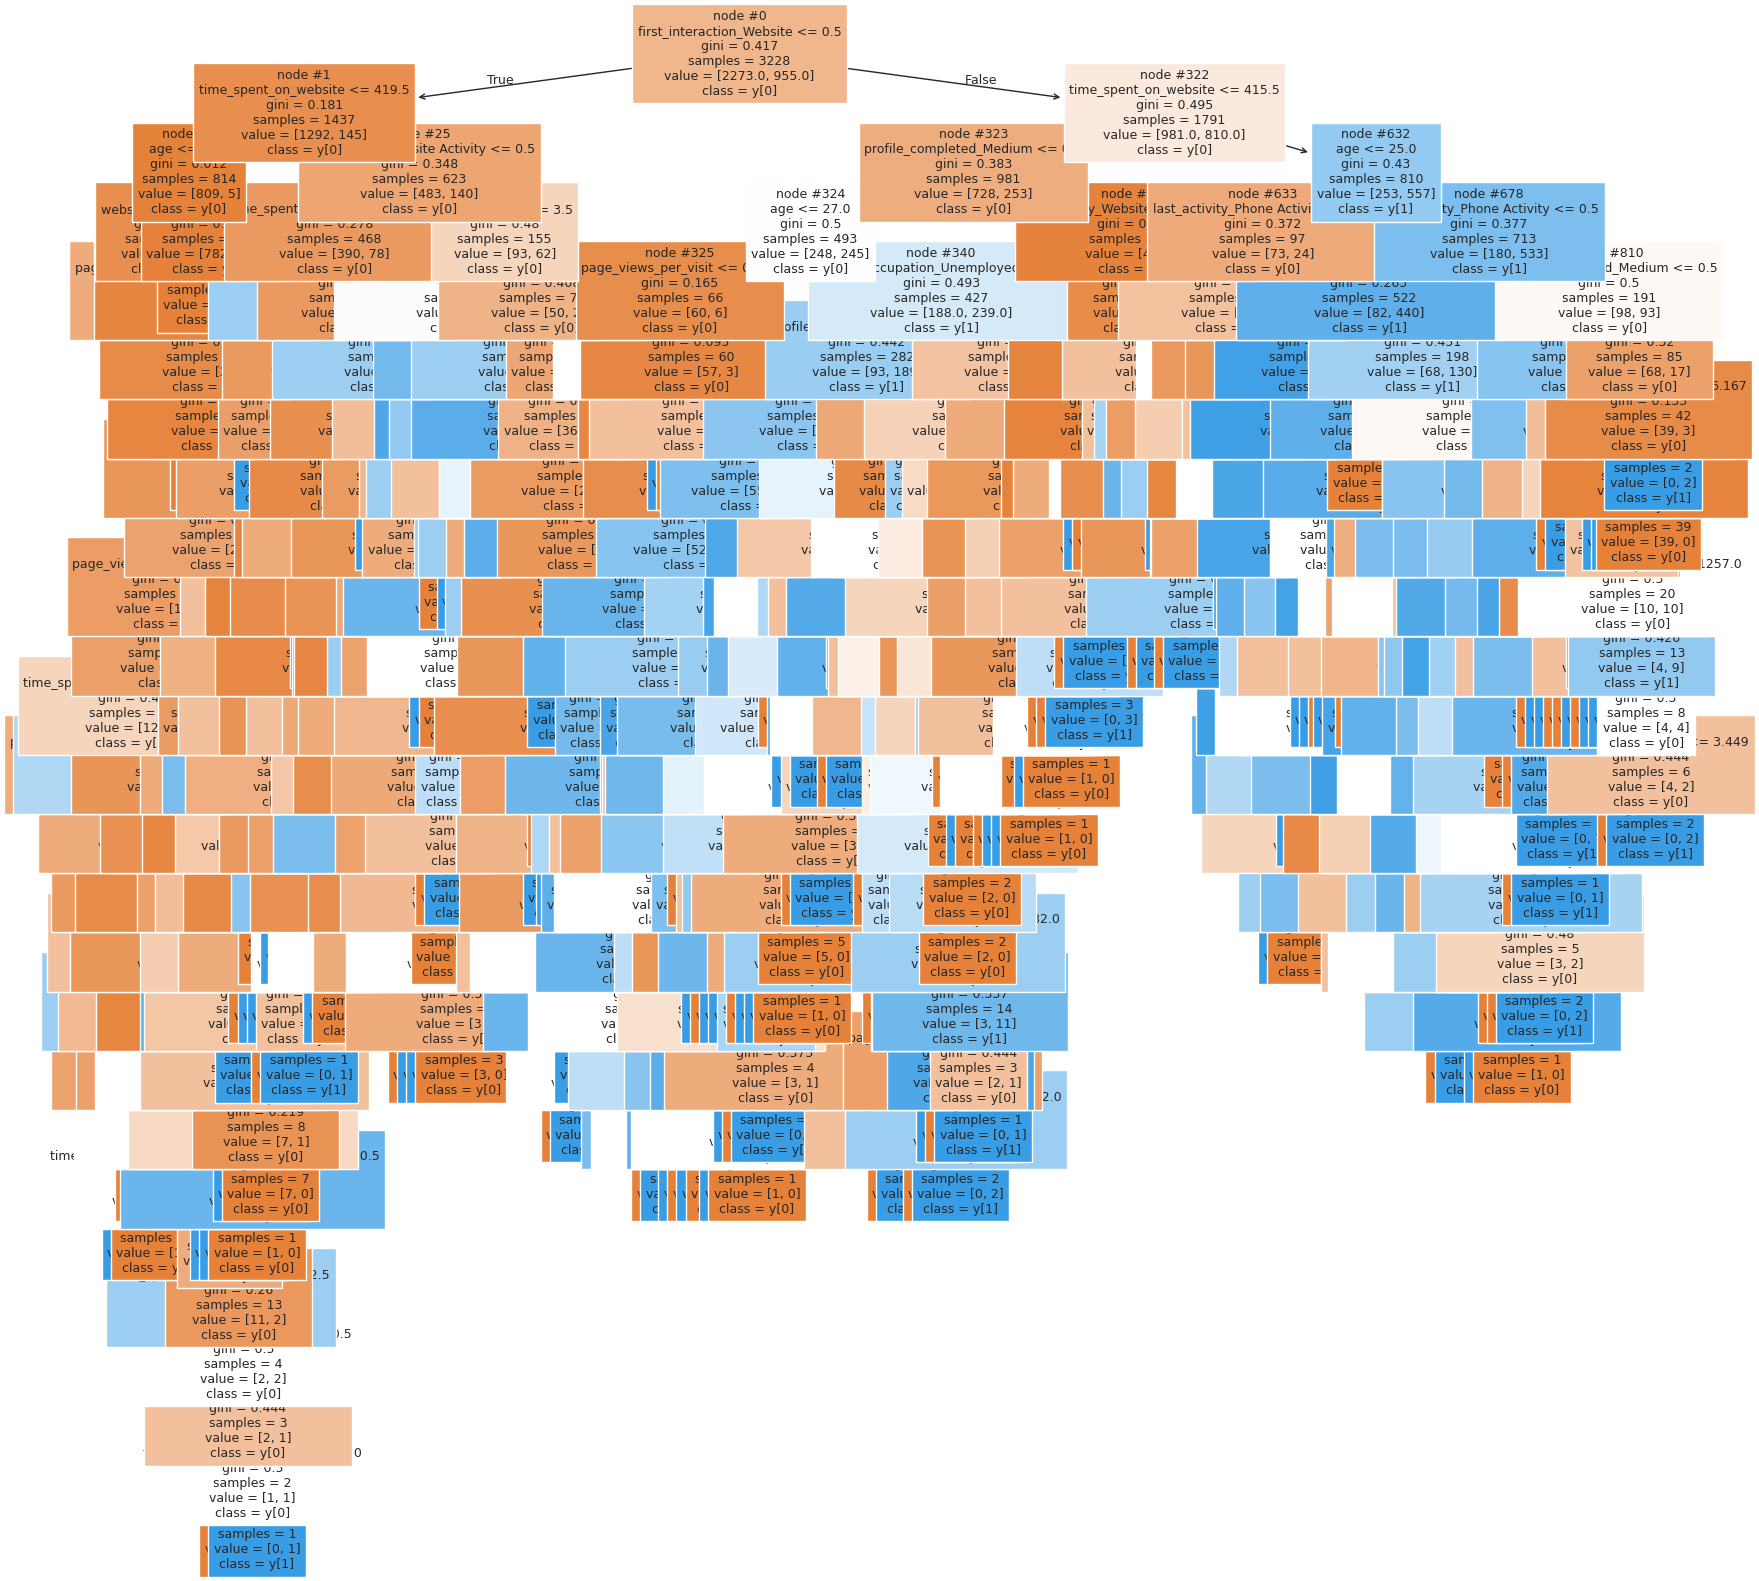

In [ ]:
# Let's use this code to visualize the tree so we can see thee difference before and after pruning.
features = list(X.columns)

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tree, feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

As we can see, this tree is so oversaturated that it is impossible to visualize the entire tree.  This just adds to why we should now attempt to prune the tree.

In [ ]:
# Choose the type of classifier.  We can use the class_weight hyperparameter to offset the imbalance in our data (1:30 percent, 0:70 percent)
d_tuned_tree = DecisionTreeClassifier(random_state=1, class_weight = {0: 0.3, 1: 0.7})

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(2,10),
    "criterion": ['entropy','gini'],
    "min_samples_leaf": [5, 10, 15, 20,25],
}
# Run the grid search
grid_obj = GridSearchCV(d_tuned_tree, parameters, cv=5,scoring='recall')
grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
d_tuned_tree = grid_obj.best_estimator_

# Fit the best algorithm to the data.
d_tuned_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=np.int64(3), min_samples_leaf=5,
                       random_state=1)

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      2273
           1       0.62      0.88      0.73       955

    accuracy                           0.80      3228
   macro avg       0.78      0.83      0.79      3228
weighted avg       0.84      0.80      0.81      3228



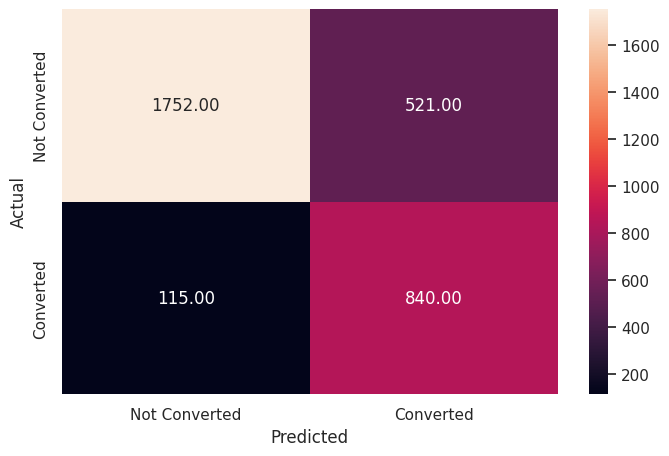

In [ ]:
# Checking performance on the training data
y_pred_train2 = d_tuned_tree.predict(X_train)
metrics_score(y_train, y_pred_train2)

For training data this tuned model has more errors in prediction but being that our untuned model overfit the data this model could still be better despite looking worse on the training data.  Let's check on the testing data

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       962
           1       0.62      0.86      0.72       422

    accuracy                           0.80      1384
   macro avg       0.77      0.82      0.78      1384
weighted avg       0.83      0.80      0.80      1384



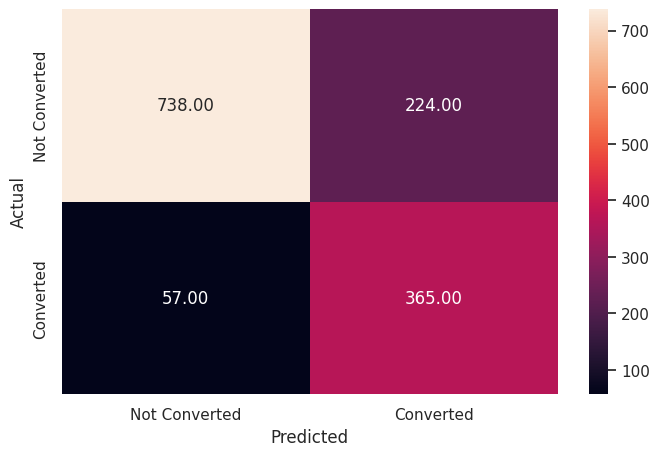

In [ ]:
# Checking performance on the test data
y_pred_test2 = d_tuned_tree.predict(X_test)
metrics_score(y_test, y_pred_test2)

Comparing this model to the untuned decision tree we can see that we achieved our goal in getting a better model.  We wanted to minimize false negatives where we were ok with more false positives because they would be less impactful than losing out on customers.  From the comparison we can see that the tuned model has done just that.  The false positives have increased from 121 to 224 but our false negatives have decreased from 128 to 57.  This model is a solid working model that we will compare to a random forest model in a little bit to see which model would be the best for our company.

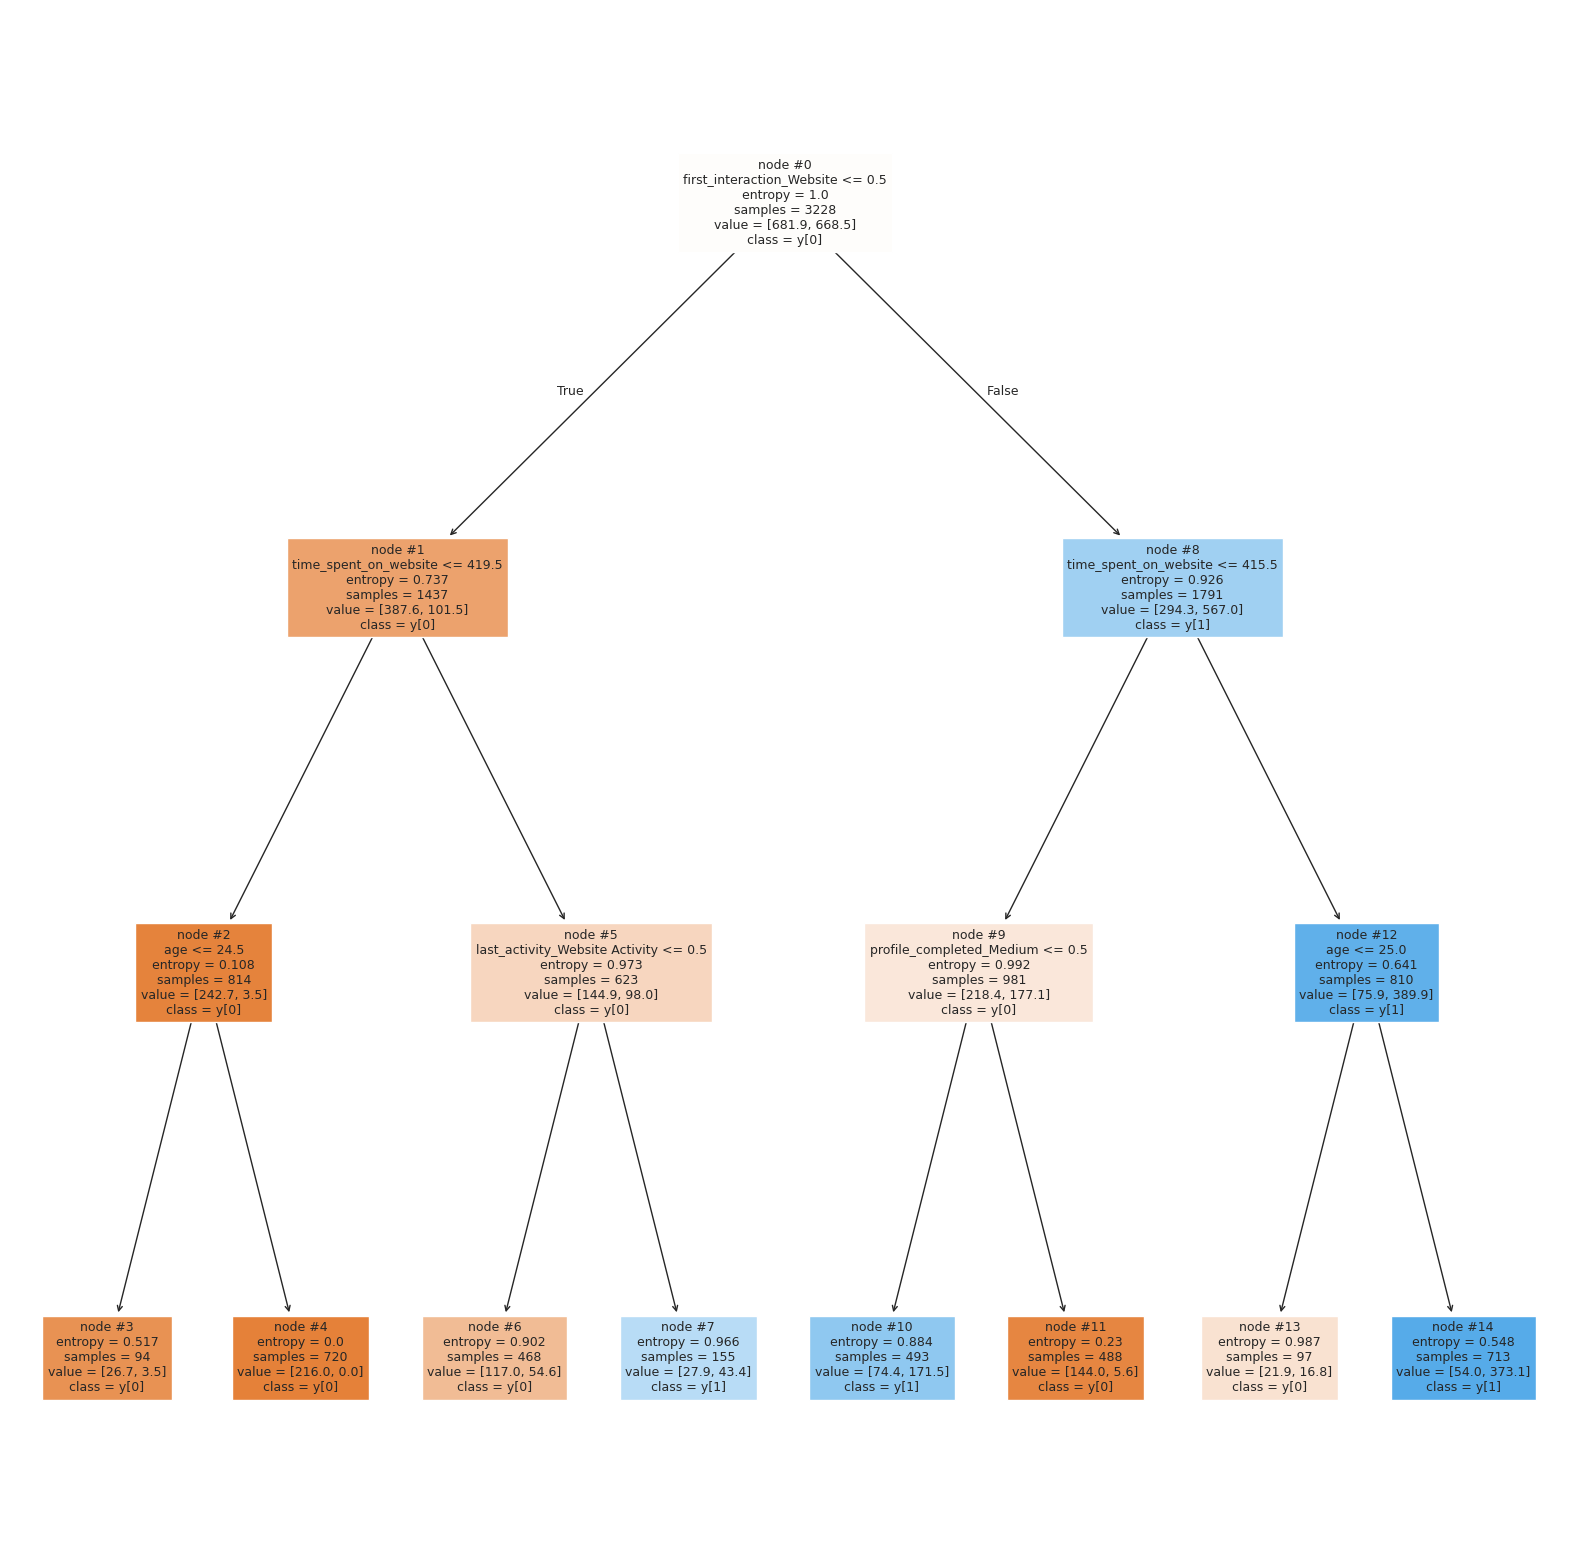

In [ ]:
# Plots the tuned (pruned) decision tree
features = list(X.columns)

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tuned_tree, feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

Just by looking at this tree we can see how it is much more readable as well as more efficient it is.  This is due to the fact that we don't have to run through a tree that is super deep.  Therefore, we decrease our false negatives and get a more interpretable tree in one fell swoop.

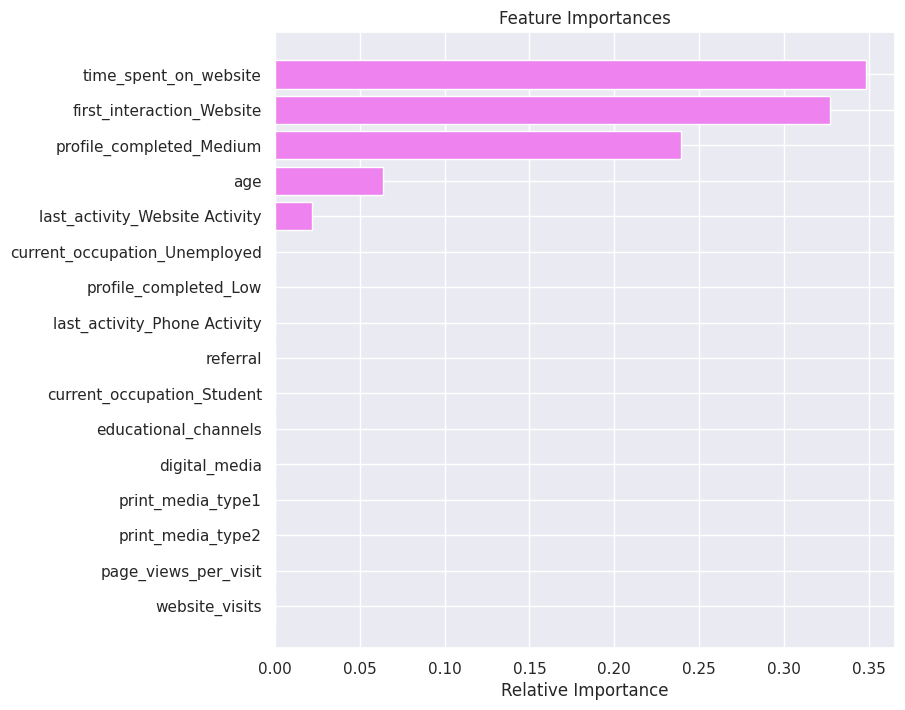

In [ ]:
# Before going on to our Random Forest model we will check and plot the feature importances in our tuned tree
importances = d_tuned_tree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

This plot tells us that the most important features are time_spent_on_website, first_interaction_on_Website, profile_completed_Medium, age, and last_activity_Website Activity in that order.  The remainder of the features appear to have no impact on predictions made by our model.  Now let's build a random forest model and compare our findings.

## Building a Random Forest model

In [ ]:
# First we instantiate the model and fit the model to our data
r_forest = RandomForestClassifier(random_state=1)
r_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



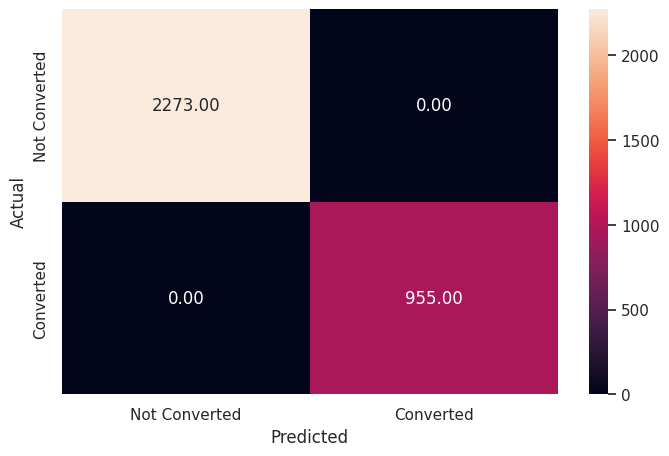

In [ ]:
# Testing the model's performance on the training data
y_pred_train_rf = r_forest.predict(X_train)
metrics_score(y_train, y_pred_train_rf)

* Looks like our model has performed very well and each sample has been classified correctly just like our initial decision tree did on the training data.
* This looks like we could have the same problems as we did with our decision tree so let's check the performance on test data to see if our model is overfitting.

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       962
           1       0.80      0.68      0.74       422

    accuracy                           0.85      1384
   macro avg       0.84      0.80      0.82      1384
weighted avg       0.85      0.85      0.85      1384



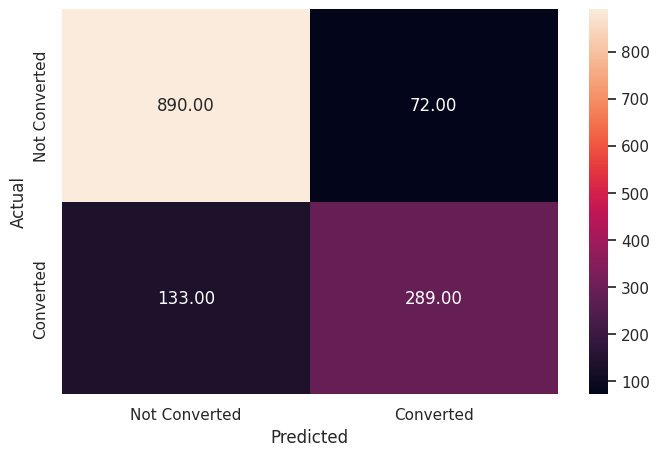

In [ ]:
# Testing the model's performance on the test data
y_pred_test_rf = r_forest.predict(X_test)
metrics_score(y_test, y_pred_test_rf)

* Looks like our model performs better on our test data than the decision tree in terms of sheer amount of wrong predictions, but is still overfitting our training data due to the substantial amount of incorrect predictions on the test data.
*   We also have a higher amount of type 2 errors than type 1 which is not what we are looking for.
* We should try and tune our random forest to reduce overfitting and make our model more accurate.

## Do we need to prune the tree?

In [ ]:
# We will tune the hyperparameters to try and get a more accurate model
# Choose the type of classifier.
r_tuned_forest = RandomForestClassifier(random_state=1,criterion='entropy')

# Grid of parameters to choose from
parameters = {
    "max_depth": [4,5,6,7],
    'n_estimators': [110,120],
    "max_features": [0.8,0.9,1],
    "max_samples": [0.8,0.9,1],
    "min_samples_leaf": [15,20,25],
    "class_weight": ["balanced",{0: 0.3, 1: 0.7}]
}
# Run the grid search
grid_obj = GridSearchCV(r_tuned_forest, parameters, cv=5,scoring='recall')
grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
r_tuned_forest = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
r_tuned_forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=4, max_features=0.9, max_samples=0.9,
                       min_samples_leaf=20, n_estimators=110, random_state=1)

              precision    recall  f1-score   support

           0       0.95      0.79      0.86      2273
           1       0.64      0.89      0.74       955

    accuracy                           0.82      3228
   macro avg       0.79      0.84      0.80      3228
weighted avg       0.86      0.82      0.82      3228



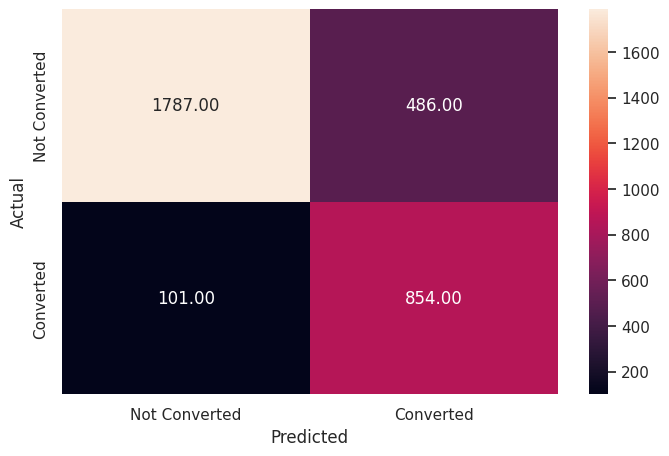

In [ ]:
# Now we will check the performance of the tuned random forest model on the training data
y_pred_train_rf_tuned = r_tuned_forest.predict(X_train)
metrics_score(y_train, y_pred_train_rf_tuned)

The tuned random forest model looks to perform better than the tuned decision tree on the training data.  We go from 115 type 2 errors and 521 type 1 errors with the tuned decision tree to 101 type 2 errors and 486 type 1 errors with the tuned random forest.  So the random forest increases recall and is more accurate in terms of predictions boasting about 50 less errors.  Just looking at the training data, this model looks as if it minimizes the loss in revenue more over the decision tree but let's look at the performance on the testing data to really cement our findings.

              precision    recall  f1-score   support

           0       0.94      0.79      0.86       962
           1       0.65      0.87      0.75       422

    accuracy                           0.82      1384
   macro avg       0.79      0.83      0.80      1384
weighted avg       0.85      0.82      0.82      1384



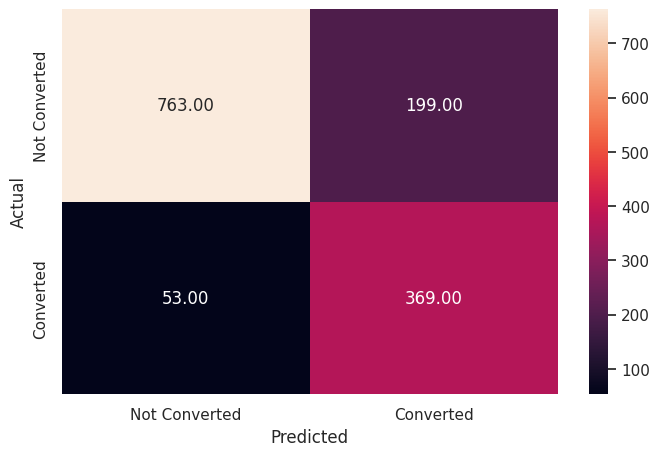

In [ ]:
# Now we will check the performance of the tuned random forest model on the test data
y_pred_test_rf_tuned = r_tuned_forest.predict(X_test)
metrics_score(y_test, y_pred_test_rf_tuned)

The tuned random forest model looks to perform better than the tuned decision tree on the test data as well.  We go from 57 type 2 errors and 224 type 1 errors with the tuned decision tree to 53 type 2 errors and 199 type 1 errors with the tuned random forest.  So the random forest increases recall and is more accurate in terms of predictions with about 30 less errors.  Now from looking on the both sets of data we can say that in our case we should use the tuned random forest model as it maximizes recall, and makes more accurate predictions (minimizing Type 1 and Type 2 errors) that will in turn help the company become more profitable.  Before we conclude our insights let's check the feature importance for our tuned random forest model.

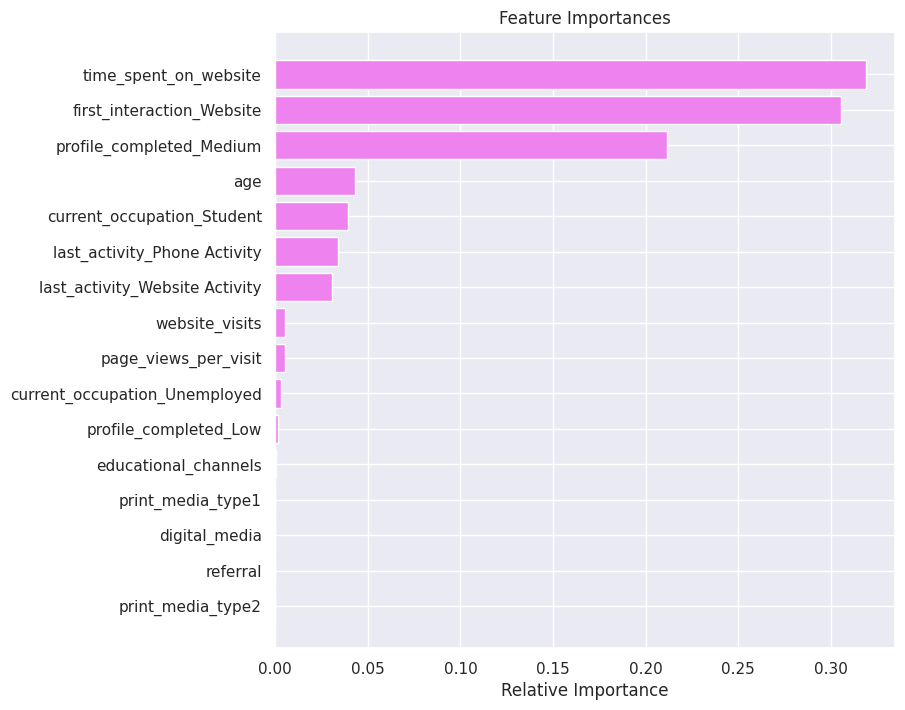

In [ ]:
# We will check and plot the feature importances in our tuned random forest
# This is the only visual interpretation we get of the random forest since we can't plot it as we did the decision tree as it is a set of trees.
importances = r_tuned_forest.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

This plot tells us that the 4 most important features are time_spent_on_website, first_interaction_on_Website, profile_completed_Medium and age in that order which is exactly the same as the decision tree.  The random forest model gives importance to more features such as current_occupation_Student, website_visits, page_views_per_visit, current_occupation_Unemployed, etc.  Now we can make our final few recommendations to help ExtraaLearn become more profitable in the future.

## Actionable Insights and Recommendations

In summary, here are some of the insights and recommendations that I would present to ExtraaLearn based on the data analysis and models trained throughout this assignment:
*   current_occupation showed us that only 12 percent of potential leads are in the student category. Being that this service is targeted towards professionals and students, professionals making up a large portion of leads makes perfect sense whereas students seem to be on the low end. We might want to try and target students even more if possible with ads or emails more catered toward them/their interests.
*    profile_completed told us that 97.7 percent of potential leads have at least 50 percent of their profile completed which is good for us because we can use that information to target courses or ads to users who we think might be interested in them. We could also try and send extra reminders to users in the low category to get them to update their profile.  From the barplots we saw that having more information about a potential lead does increase the chance of conversion. The chance of conversion increases from about 7 percent to about 19 percent to about 42 percent when going from low to medium to high profile completion. In order to try and maximize our chances at more paying customers we can incentivize potential leads by giving them a reward (something like 5 percent off their first course enrollment) when they hit over the 75 percent profile completion that puts them into the high category.
*   last_activity showed 49.4 percent of potential leads having their last interaction with ExtraaLearn via email. From this we can see that most people interact with the company via email, so, sending out more important messages via email, rather than by phone or website, could be more beneficial to the company.  The barplots showed us that last interaction has an impact on lead status. We saw that almost 40 percent of potential leads that have their last interaction via the website convert to paying customers while about 30 percent of potential leads that have their last interaction via email convert to paying customers, and about 21 percent of potential leads that have their last interaction via the phone convert to paying customers. From those numbers it might be best to try and keep on top of those who use the website in order to maximize conversion. In the future we could also do some deeper research and segment these leads into age brackets and see if it is better to contact certain age groups in different ways. For example, maybe people ages 50-60 could have a higher converison rate if contacted by phone instead of email or vice versa for the age group of 20-30.
*   first channel of interaction absolutely had an impact on lead status. We saw that 46 percent of potential leads that have their first interaction on the website convert to paying customers while only about 11 percent of potential leads that have their first interaction on the app convert to paying customers. From these numbers it might be best to add more features to the website to attract customers to try and maximize those website numbers. On the other hand, one could also try adding more features to the app to try and raise that percentage somewhere close to the website numbers but being as the mobile app numbers are starting rather low, this approach would probably be more on the riskier side.
*   From the barplots of each type of recruiting techniques we saw most don't show much of a difference in conversion rate whether the person had seen the ad or not except one. Referral had a large difference in conversion rate for people who had been referred and had not. The conversion rate jumped from about 30 percent to about 68 percent if the person is referred. This means that more referrals gives us a higher chance that these potential leads turn into paying customers and make the company more money. Therefore, giving already paying customers referral codes where they can get gift cards or some other perks if a person joins with their code would give these customers a greater incentive to tell some friends if they were enjoying our services.
*   The tuned random forest model performed better than the tuned decision tree on both the training and test data.  From looking on the both sets of data we can say that in our case we should use the tuned random forest model when trying to predict the status of a potential lead as it maximizes recall, and makes more accurate predictions (minimizing Type 1 and Type 2 errors) that will in turn help the company become more profitable.





